# การเตรียมข้อมูล ฝึกโมเดล และประเมิน UV ใน notebook เดียว

โมเดลนี้ฝึก SARIMAX **ในเครื่อง** แยกกรุงเทพ สงขลา และเชียงใหม่ เป้าหมายคือ TEMIS UV ภายใต้ท้องฟ้าโปร่ง ณ เที่ยงสุริยะ ไม่ใช่ UV ที่ผู้ใช้ได้รับจริง และไม่ได้เรียก API โมเดลพยากรณ์สำเร็จรูป

**การรันรอบนี้:** เซลล์เตรียมข้อมูลและฝึกโมเดลด้านล่าง *นิยามฟังก์ชันเท่านั้น* ไม่มีการเรียกดาวน์โหลดหรือ `fit()` เมื่อกด Run All เซลล์ประเมินอ่าน CSV, metrics และผล backtest ที่เคยบันทึกไว้ ตรวจความสอดคล้อง แล้วสร้างตารางและกราฟใหม่ หากไฟล์เหล่านั้นหาย notebook จะหยุดพร้อมข้อความชัดเจนแทนการฝึกใหม่อัตโนมัติ

In [1]:
from pathlib import Path
from datetime import date
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError("Run this notebook inside the Aphrodize repository")

plt.style.use("ggplot")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
CITY_LABELS = {"bangkok": "Bangkok", "songkhla": "Songkhla", "chiang_mai": "Chiang Mai"}
print("Repository:", ROOT)


Repository: D:\CoE Y.4 T.1\241-353\code\Aphrodize


## 1. เตรียมข้อมูล TEMIS

โค้ดต่อไปนี้คือขั้นเตรียมข้อมูลจาก `scripts/prepare_uv_dataset.py` ที่รวมไว้ใน notebook เพื่อให้อ่านจบในไฟล์เดียว ฟังก์ชัน `prepare_uv_data()` ดาวน์โหลดไฟล์รายวันของสามพื้นที่ ตรวจหัว `UVIEF`, 17 คอลัมน์, วันที่ต่อเนื่อง และค่าผิดปกติ ก่อนเขียน `storage/data/uv/temis_clear_sky_uv.csv`; ค่า `-1` กลายเป็นค่าว่าง **เซลล์นี้แค่นิยามฟังก์ชัน ไม่เรียกใช้**

In [2]:
"""Download and validate TEMIS daily clear-sky UV data for three Thai cities."""

import csv
import hashlib
import math
from datetime import date, timedelta
from pathlib import Path
from urllib.request import Request, urlopen


SOURCES = {
    "bangkok": "uv_Bangkok_Thailand.dat",
    "songkhla": "uv_Songkhla_Thailand.dat",
    "chiang_mai": "uv_Chiang_Mai_Thailand.dat",
}
BASE_URL = "https://d1qb6yzwaaq4he.cloudfront.net/uvradiation/v2.0/overpass/"
OUTPUT = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"


def parse_series(city: str, content: bytes) -> list[tuple[str, str, str, str]]:
    source = content.decode("utf-8")
    if "2, 3 = UVIEF, UVIEFerr" not in source:
        raise ValueError(f"{city}: TEMIS UVIEF column definition not found")
    rows = []
    previous = None
    for line_number, line in enumerate(source.splitlines(), 1):
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        fields = line.split()
        if len(fields) != 17:
            raise ValueError(f"{city}:{line_number}: expected 17 columns, got {len(fields)}")
        if len(fields[0]) != 8 or not fields[0].isdigit():
            raise ValueError(f"{city}:{line_number}: invalid date {fields[0]}")
        day = date.fromisoformat(f"{fields[0][:4]}-{fields[0][4:6]}-{fields[0][6:8]}")
        if previous is not None and day != previous + timedelta(days=1):
            raise ValueError(f"{city}:{line_number}: date after {previous} is {day}")
        previous = day
        values = []
        for value in fields[1:3]:
            number = float(value)
            if not math.isfinite(number) or (number < 0 and number != -1):
                raise ValueError(f"{city}:{line_number}: invalid UV value {value}")
            values.append("" if number == -1 else value)
        rows.append((day.isoformat(), city, *values))
    if not rows:
        raise ValueError(f"{city}: no daily records")
    return rows


def main() -> None:
    all_rows = []
    for city, filename in SOURCES.items():
        request = Request(BASE_URL + filename, headers={"User-Agent": "Aphrodize-UV-Research/1.0"})
        with urlopen(request, timeout=60) as response:
            content = response.read()
        rows = parse_series(city, content)
        all_rows.extend(rows)
        missing = sum(not row[2] for row in rows)
        print(f"{city}: {len(rows)} dates, {rows[0][0]} to {rows[-1][0]}, "
              f"{missing} missing UV values, SHA-256 {hashlib.sha256(content).hexdigest()}")

    OUTPUT.parent.mkdir(parents=True, exist_ok=True)
    temporary = OUTPUT.with_suffix(".csv.tmp")
    try:
        with temporary.open("w", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)
            writer.writerow(("date", "city", "uv_index_clear_sky", "uv_index_uncertainty"))
            writer.writerows(sorted(all_rows))
        temporary.replace(OUTPUT)
    finally:
        temporary.unlink(missing_ok=True)
    print(f"Wrote {len(all_rows)} rows to {OUTPUT}")


ตารางต่อไปอ่าน CSV **ปัจจุบัน** ที่มีอยู่ในเครื่องเท่านั้น เพื่อยืนยันช่วงวันที่และจำนวนค่าว่างโดยไม่ดาวน์โหลดข้อมูลใหม่ CSV นี้อาจไม่ใช่ snapshot เดียวกับที่ฝึกโมเดล จึงไม่ใช้ค่าจากตารางนี้ในการคำนวณคะแนนด้านล่าง

In [3]:
if not OUTPUT.exists():
    raise FileNotFoundError(
        f"{OUTPUT} is missing. This notebook will not download or retrain automatically."
    )
summary = {}
with OUTPUT.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        item = summary.setdefault(row["city"], {"rows": 0, "first": row["date"], "last": row["date"], "missing": 0})
        item["rows"] += 1
        item["last"] = row["date"]
        item["missing"] += not bool(row["uv_index_clear_sky"])
display(Markdown("| City | Rows | First date | Last date | Missing UV |\n|---|---:|---|---|---:|\n" +
                 "\n".join(f"| {CITY_LABELS[city]} | {item['rows']} | {item['first']} | {item['last']} | {item['missing']} |"
                           for city, item in summary.items())))


| City | Rows | First date | Last date | Missing UV |
|---|---:|---|---|---:|
| Bangkok | 8857 | 2002-07-01 | 2026-09-29 | 0 |
| Chiang Mai | 8857 | 2002-07-01 | 2026-09-29 | 0 |
| Songkhla | 8857 | 2002-07-01 | 2026-09-29 | 0 |

## 2. ฝึก SARIMAX ในเครื่อง

โค้ดที่รวมจาก `scripts/train_uv_model.py` สร้าง Fourier sine/cosine สอง harmonic ต่อปี (4 ตัวแปรที่ทราบจากวันที่), ทดลอง order `(1,0,0)`, `(2,0,0)`, `(3,0,0)`, `(1,0,1)` สำหรับแต่ละเมือง แล้วเลือกจาก MAE ของการทำนายล่วงหน้า 2 วันใน validation ปี 2024 ข้อมูลถึง 2023-12-31 ใช้ฝึก และปี 2025 เป็นต้นไปกันเป็น test การ backtest เดินทีละวันโดยใช้ค่าจริงที่มีถึงจุดพยากรณ์เท่านั้น

`train_uv_models()` จะฝึกและบันทึกไฟล์ `.pkl` หากมีคน **เรียกฟังก์ชันนี้เอง** เท่านั้น รอบนี้ไม่มีเซลล์ใดเรียกมัน โค้ด production อยู่ในสคริปต์ต้นทาง ซึ่งเป็นแหล่งอ้างอิงเมื่อแก้ไขระบบจริง

In [4]:
"""Backtest and locally train clear-sky UV SARIMAX models for three cities."""

import csv
import hashlib
import json
import math
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX


DATA = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"
ARTIFACTS = ROOT / "storage/artifacts/uv"
MODELS = ROOT / "storage/models/uv"
CITIES = ("bangkok", "songkhla", "chiang_mai")
ORDERS = ((1, 0, 0), (2, 0, 0), (3, 0, 0), (1, 0, 1))
TRAIN_END = date(2023, 12, 31)
VALID_END = date(2024, 12, 31)


def load_data():
    series = {city: ([], []) for city in CITIES}
    with DATA.open(newline="", encoding="utf-8") as file:
        for row in csv.DictReader(file):
            city = row["city"]
            if city not in series:
                raise ValueError(f"Unknown city: {city}")
            day = date.fromisoformat(row["date"])
            if not row["uv_index_clear_sky"]:
                raise ValueError(f"Missing UV value: {city} {day}; resolve before training")
            uv = float(row["uv_index_clear_sky"])
            if not math.isfinite(uv) or uv < 0:
                raise ValueError(f"Invalid UV value: {city} {day}")
            days, values = series[city]
            if days and day != days[-1] + timedelta(days=1):
                raise ValueError(f"Nonconsecutive date: {city} {day}")
            days.append(day)
            values.append(uv)
    for city, (days, _) in series.items():
        if not days or days[0] > TRAIN_END or days[-1] <= VALID_END:
            raise ValueError(f"Insufficient date range: {city}")
    return series


def fourier(days):
    elapsed = np.array([day.toordinal() - date(2000, 1, 1).toordinal() for day in days])
    return np.column_stack(
        [function(2 * np.pi * harmonic * elapsed / 365.2425)
         for harmonic in (1, 2) for function in (np.sin, np.cos)]
    )


def fit_model(values, features, order):
    result = SARIMAX(
        values, exog=features, order=order, trend="c", enforce_stationarity=True
    ).fit(disp=False, maxiter=100)
    if not result.mle_retvals.get("converged"):
        raise RuntimeError("SARIMAX optimization did not converge")
    return result


def rolling_forecasts(result, days, values, features, start, stop):
    """Each prediction uses only observations through its forecast origin."""
    one_day = np.empty(stop - start)
    two_days = np.full(stop - start, np.nan)
    for offset, index in enumerate(range(start, stop)):
        future = (days[index], days[index] + timedelta(days=1))
        predicted = result.get_forecast(steps=2, exog=fourier(future)).predicted_mean
        one_day[offset] = predicted[0]
        if offset + 1 < len(two_days):
            two_days[offset + 1] = predicted[1]
        result = result.extend(values[index:index + 1], exog=features[index:index + 1])
    return one_day, two_days


def seasonal_baseline(days, values, start, stop):
    known = dict(zip(days, values, strict=True))
    predicted = []
    for day in days[start:stop]:
        try:
            previous_year = day.replace(year=day.year - 1)
        except ValueError:  # 29 February
            previous_year = day.replace(year=day.year - 1, day=28)
        predicted.append(known[previous_year])
    return np.array(predicted)


def score(actual, predicted):
    mask = np.isfinite(predicted)
    error = actual[mask] - predicted[mask]
    return {"n": int(mask.sum()), "mae": round(float(np.mean(np.abs(error))), 4),
            "rmse": round(float(np.sqrt(np.mean(error ** 2))), 4)}


def train_uv_models():
    series = load_data()
    data_hash = hashlib.sha256(DATA.read_bytes()).hexdigest()
    summary = {"source_sha256": data_hash, "model": "SARIMAX + 2 annual Fourier harmonics",
               "selection_metric": "validation two-day MAE",
               "statsmodels": statsmodels.__version__, "cities": {}}
    predictions = []
    MODELS.mkdir(parents=True, exist_ok=True)
    ARTIFACTS.mkdir(parents=True, exist_ok=True)

    for city, (days, raw_values) in series.items():
        values = np.asarray(raw_values)
        features = fourier(days)
        train_stop = next(i for i, day in enumerate(days) if day > TRAIN_END)
        valid_stop = next(i for i, day in enumerate(days) if day > VALID_END)
        candidates = {}
        selected = None
        for order in ORDERS:
            fitted = fit_model(values[:train_stop], features[:train_stop], order)
            one_day, two_days = rolling_forecasts(
                fitted, days, values, features, train_stop, valid_stop
            )
            key = str(order)
            candidates[key] = score(values[train_stop:valid_stop], two_days)
            exact_mae = float(np.mean(np.abs(values[train_stop + 1:valid_stop] - two_days[1:])))
            if selected is None or exact_mae < selected[3]:
                selected = (order, one_day, two_days, exact_mae)
        order, valid_one_day, valid_two_days, _ = selected
        city_scores = {"selected_order": list(order), "validation_candidates": candidates}

        for split, start, stop in (("validation", train_stop, valid_stop),
                                   ("test", valid_stop, len(days))):
            if split == "validation":
                one_day, two_days = valid_one_day, valid_two_days
            else:
                fitted = fit_model(values[:start], features[:start], order)
                one_day, two_days = rolling_forecasts(
                    fitted, days, values, features, start, stop
                )
            actual = values[start:stop]
            seasonal = seasonal_baseline(days, values, start, stop)
            persistence = values[start - 1:stop - 1]
            persistence_two = values[start - 1:stop - 1].copy()
            persistence_two[1:] = values[start - 1:stop - 2]
            persistence_two[0] = np.nan
            city_scores[split] = {
                "sarimax_h1": score(actual, one_day),
                "sarimax_h2": score(actual, two_days),
                "seasonal_naive": score(actual, seasonal),
                "persistence_h1": score(actual, persistence),
                "persistence_h2": score(actual, persistence_two),
            }
            for index, day in enumerate(days[start:stop]):
                predictions.append((city, split, day.isoformat(), actual[index], one_day[index],
                                    two_days[index] if index else "", seasonal[index],
                                    persistence[index], persistence_two[index] if index else ""))

        final = fit_model(values, features, order)
        final.save(MODELS / f"{city}.pkl")
        city_scores["trained_through"] = days[-1].isoformat()
        future_days = (days[-1] + timedelta(days=1), days[-1] + timedelta(days=2))
        future_values = final.get_forecast(steps=2, exog=fourier(future_days)).predicted_mean
        city_scores["next_two_days_clear_sky"] = {
            day.isoformat(): round(float(value), 3)
            for day, value in zip(future_days, future_values, strict=True)
        }
        summary["cities"][city] = city_scores
        print(f"{city}: selected {order}, validation h2 MAE "
              f"{city_scores['validation']['sarimax_h2']['mae']}, "
              f"test h2 MAE {city_scores['test']['sarimax_h2']['mae']}")

    (ARTIFACTS / "metrics.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )
    with (ARTIFACTS / "backtest_predictions.csv").open("w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(("city", "split", "date", "actual", "sarimax_h1", "sarimax_h2",
                         "seasonal_naive", "persistence_h1", "persistence_h2"))
        writer.writerows(predictions)
    print(f"Saved models to {MODELS} and backtest results to {ARTIFACTS}")


## 3. ประเมินผลที่บันทึกไว้

ส่วนนี้เป็นส่วนที่รันจริง ใช้ `metrics.json` กับ `backtest_predictions.csv` ที่ได้จากการฝึกครั้งก่อน ตรวจค่า SHA-256 ของ CSV ปัจจุบันและแจ้งเมื่อไม่ตรงกับ snapshot ตอนฝึก จากนั้นตรวจจำนวนแถวและ MAE ของ backtest กับ metrics เดิมก่อนคำนวณ `evaluation.json` ใหม่ **ผลประเมินอ้างอิง backtest ที่บันทึกไว้ ไม่ใช่การทำนายจาก CSV ปัจจุบัน** ไม่โหลดโมเดล `.pkl` และไม่เรียก `SARIMAX.fit()` กราฟทั้งหมดด้านล่างใช้ผลทำนายล่วงหน้า 2 วันที่บันทึกไว้

In [5]:
"""Audit held-out two-day UV forecasts before using them in the app."""

import csv
import hashlib
import json
from collections import defaultdict
from datetime import date
from pathlib import Path

import numpy as np


ARTIFACTS = ROOT / "storage/artifacts/uv"
DATA = ROOT / "storage/data/uv/temis_clear_sky_uv.csv"
THRESHOLDS = (8, 11)


def block_bootstrap_ci(improvements, *, block=14, repeats=2000, seed=42):
    """Percentile interval for paired daily MAE gains, retaining short-run dependence."""
    gains = np.asarray(improvements, dtype=float)
    if len(gains) < block:
        raise ValueError("Not enough test days for a block bootstrap")
    rng = np.random.default_rng(seed)
    starts = rng.integers(0, len(gains) - block + 1,
                          size=(repeats, (len(gains) + block - 1) // block))
    samples = (starts[:, :, None] + np.arange(block)).reshape(repeats, -1)[:, :len(gains)]
    return [round(float(value), 4) for value in np.quantile(gains[samples].mean(axis=1),
                                                            (0.025, 0.975))]


def threshold_counts(actual, predicted, threshold):
    # Public UV categories use whole-number UVI, so compare displayed values.
    actual_high = np.floor(actual + 0.5) >= threshold
    predicted_high = np.floor(predicted + 0.5) >= threshold
    return {
        "actual_at_or_above": int(actual_high.sum()),
        "undercalled": int((actual_high & ~predicted_high).sum()),
        "false_alarms": int((~actual_high & predicted_high).sum()),
    }


def evaluate_saved_backtest():
    metrics = json.loads((ARTIFACTS / "metrics.json").read_text(encoding="utf-8"))
    if hashlib.sha256(DATA.read_bytes()).hexdigest() != metrics["source_sha256"]:
        print("NOTICE: Current CSV differs from the training snapshot; the evaluation below uses saved backtest rows only.")

    grouped = defaultdict(list)
    with (ARTIFACTS / "backtest_predictions.csv").open(newline="", encoding="utf-8") as file:
        for row in csv.DictReader(file):
            if row["split"] == "test" and row["sarimax_h2"]:
                grouped[row["city"]].append(row)
    if set(grouped) != set(metrics["cities"]):
        raise ValueError("Prediction cities do not match training metrics")

    report = {"horizon_days": 2, "split": "test", "bootstrap_block_days": 14,
              "bootstrap_repeats": 2000, "cities": {}}
    for city, rows in grouped.items():
        days = [date.fromisoformat(row["date"]) for row in rows]
        if len(set(days)) != len(days) or days != sorted(days):
            raise ValueError(f"Duplicate or unsorted test dates: {city}")
        actual = np.array([float(row["actual"]) for row in rows])
        model = np.array([float(row["sarimax_h2"]) for row in rows])
        baseline = np.array([float(row["persistence_h2"]) for row in rows])
        if not np.isfinite(np.column_stack((actual, model, baseline))).all():
            raise ValueError(f"Nonfinite test value: {city}")

        absolute_error = np.abs(model - actual)
        baseline_error = np.abs(baseline - actual)
        mae = float(absolute_error.mean())
        saved = metrics["cities"][city]["test"]["sarimax_h2"]
        if len(rows) != saved["n"] or round(mae, 4) != saved["mae"]:
            raise ValueError(f"Backtest rows disagree with metrics: {city}")
        by_year = {}
        by_month = {}
        for label, groups in ((by_year, [day.year for day in days]),
                              (by_month, [day.month for day in days])):
            for key in sorted(set(groups)):
                mask = np.array([group == key for group in groups])
                label[str(key)] = {
                    "n": int(mask.sum()),
                    "model_mae": round(float(absolute_error[mask].mean()), 4),
                    "persistence_mae": round(float(baseline_error[mask].mean()), 4),
                }

        city_report = {
            "n": len(rows),
            "dates": [days[0].isoformat(), days[-1].isoformat()],
            "mae": round(mae, 4),
            "rmse": round(float(np.sqrt(np.mean((model - actual) ** 2))), 4),
            "bias_predicted_minus_actual": round(float(np.mean(model - actual)), 4),
            "p90_absolute_error": round(float(np.quantile(absolute_error, 0.9)), 4),
            "max_absolute_error": round(float(absolute_error.max()), 4),
            "persistence_mae": round(float(baseline_error.mean()), 4),
            "mae_gain_over_persistence": round(float((baseline_error - absolute_error).mean()), 4),
            "mae_gain_95pct_block_bootstrap_ci": block_bootstrap_ci(
                baseline_error - absolute_error
            ),
            "months_beating_persistence": sum(
                item["model_mae"] < item["persistence_mae"] for item in by_month.values()
            ),
            "by_year": by_year,
            "by_month": by_month,
            "thresholds": {
                str(threshold): threshold_counts(actual, model, threshold)
                for threshold in THRESHOLDS
            },
        }
        report["cities"][city] = city_report
        print(f"{city}: MAE {city_report['mae']}, gain 95% CI "
              f"{city_report['mae_gain_95pct_block_bootstrap_ci']}, "
              f"months beating persistence {city_report['months_beating_persistence']}/12")

    output = ARTIFACTS / "evaluation.json"
    output.write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
    print(f"Saved {output}")

metrics_path = ARTIFACTS / "metrics.json"
predictions_path = ARTIFACTS / "backtest_predictions.csv"
required = [DATA, metrics_path, predictions_path]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Saved evaluation inputs are missing; nothing will be downloaded or retrained: "
        + ", ".join(missing)
    )
evaluate_saved_backtest()
print("Evaluation reused the saved CSV and backtest predictions; SARIMAX was not fitted.")


NOTICE: Current CSV differs from the training snapshot; the evaluation below uses saved backtest rows only.
bangkok: MAE 0.3309, gain 95% CI [0.0429, 0.082], months beating persistence 11/12
songkhla: MAE 0.2819, gain 95% CI [0.0492, 0.0776], months beating persistence 12/12
chiang_mai: MAE 0.3482, gain 95% CI [0.044, 0.0852], months beating persistence 11/12
Saved D:\CoE Y.4 T.1\241-353\code\Aphrodize\storage\artifacts\uv\evaluation.json
Evaluation reused the saved CSV and backtest predictions; SARIMAX was not fitted.


### วิธีอ่านผล

MAE/RMSE ยิ่งต่ำยิ่งดี เปรียบเทียบ SARIMAX กับการใช้ค่า UV ล่าสุดซ้ำ (persistence) และค่าในวันเดียวกันของปีก่อน (seasonal naive) ค่า bias คือค่าทำนายลบค่าจริง ตารางและกราฟใช้ชุด test ที่กันไว้

In [6]:
metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
audit = json.loads((ARTIFACTS / "evaluation.json").read_text(encoding="utf-8"))
rows_by_city = {city: [] for city in CITIES}
with predictions_path.open(newline="", encoding="utf-8") as file:
    for row in csv.DictReader(file):
        if row["split"] == "test" and row["sarimax_h2"]:
            rows_by_city[row["city"]].append(row)

lines = ["| City | Selected SARIMAX order | Validation MAE (2 days) | Test days |",
         "|---|---:|---:|---:|"]
for city in CITIES:
    result = metrics["cities"][city]
    lines.append(f"| {CITY_LABELS[city]} | {tuple(result['selected_order'])} | "
                 f"{result['validation']['sarimax_h2']['mae']:.4f} | {len(rows_by_city[city])} |")
display(Markdown("\n".join(lines)))

| City | Selected SARIMAX order | Validation MAE (2 days) | Test days |
|---|---:|---:|---:|
| Bangkok | (1, 0, 1) | 0.3229 | 635 |
| Songkhla | (1, 0, 1) | 0.3095 | 635 |
| Chiang Mai | (1, 0, 1) | 0.3600 | 635 |

In [7]:
scores = {}
lines = ["| City | SARIMAX MAE | Latest-value MAE | Previous-year MAE | RMSE | Bias | P90 absolute error |",
         "|---|---:|---:|---:|---:|---:|---:|"]
for city, rows in rows_by_city.items():
    actual = np.array([float(row["actual"]) for row in rows])
    predicted = np.array([float(row["sarimax_h2"]) for row in rows])
    latest = np.array([float(row["persistence_h2"]) for row in rows])
    previous_year = np.array([float(row["seasonal_naive"]) for row in rows])
    scores[city] = {
        "sarimax": float(np.mean(np.abs(predicted - actual))),
        "latest": float(np.mean(np.abs(latest - actual))),
        "previous_year": float(np.mean(np.abs(previous_year - actual))),
    }
    result = audit["cities"][city]
    lines.append(f"| {CITY_LABELS[city]} | {scores[city]['sarimax']:.4f} | "
                 f"{scores[city]['latest']:.4f} | {scores[city]['previous_year']:.4f} | "
                 f"{result['rmse']:.4f} | {result['bias_predicted_minus_actual']:+.4f} | "
                 f"{result['p90_absolute_error']:.4f} |")
display(Markdown("\n".join(lines)))

| City | SARIMAX MAE | Latest-value MAE | Previous-year MAE | RMSE | Bias | P90 absolute error |
|---|---:|---:|---:|---:|---:|---:|
| Bangkok | 0.3309 | 0.3938 | 0.6199 | 0.4227 | +0.0856 | 0.6838 |
| Songkhla | 0.2819 | 0.3451 | 0.7494 | 0.3494 | +0.0566 | 0.5758 |
| Chiang Mai | 0.3482 | 0.4129 | 0.5710 | 0.4378 | +0.0978 | 0.7386 |

## 4. กราฟการประเมิน

กราฟต่อไปนี้แสดง MAE เทียบ baseline, ค่าจริงกับค่าทำนายช่วงท้าย, ความผิดพลาดรายเดือน และการกระจายของ residual

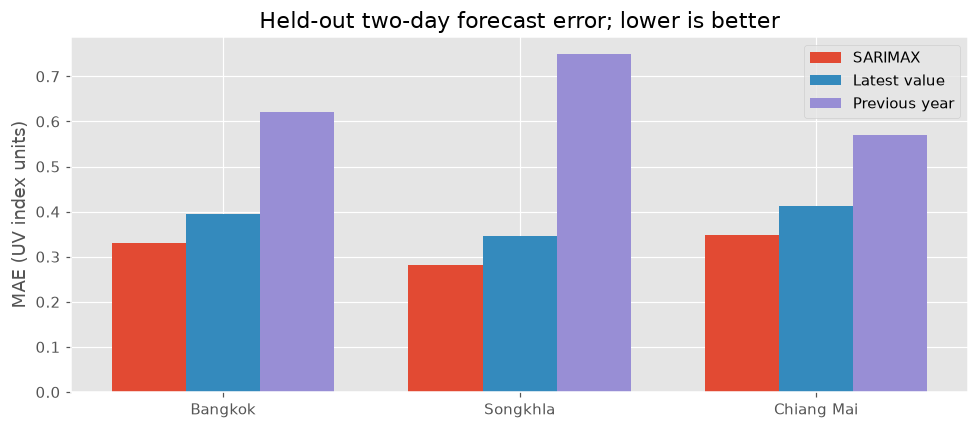

In [8]:
cities = list(CITIES)
x = np.arange(len(cities))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 4))
for offset, (key, label) in enumerate((("sarimax", "SARIMAX"), ("latest", "Latest value"),
                                       ("previous_year", "Previous year"))):
    ax.bar(x + (offset - 1) * width, [scores[city][key] for city in cities], width, label=label)
ax.set_xticks(x, [CITY_LABELS[city] for city in cities])
ax.set_ylabel("MAE (UV index units)")
ax.set_title("Held-out two-day forecast error; lower is better")
ax.legend()
plt.tight_layout()
plt.show()

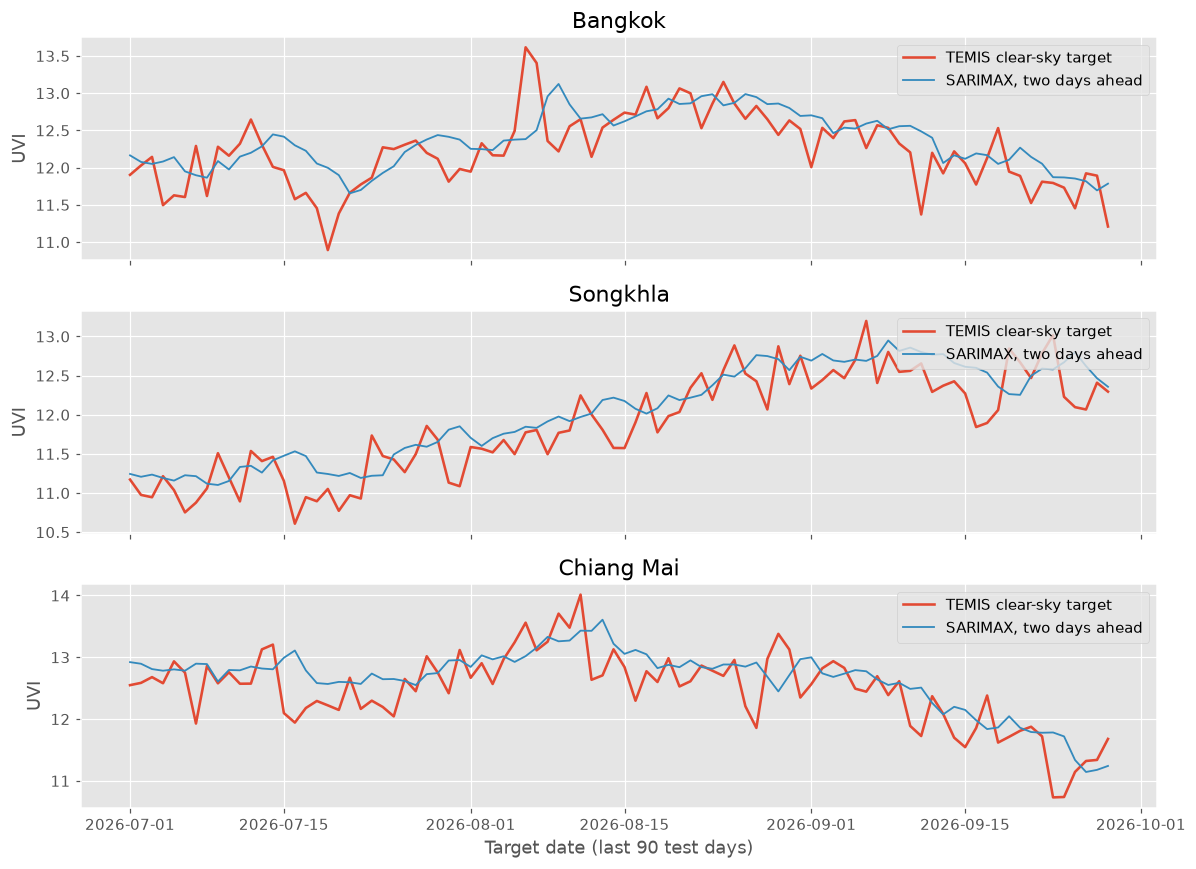

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, city in zip(axes, cities):
    recent = rows_by_city[city][-90:]
    days = [date.fromisoformat(row["date"]) for row in recent]
    ax.plot(days, [float(row["actual"]) for row in recent], label="TEMIS clear-sky target", lw=1.7)
    ax.plot(days, [float(row["sarimax_h2"]) for row in recent], label="SARIMAX, two days ahead", lw=1.2)
    ax.set_title(CITY_LABELS[city])
    ax.set_ylabel("UVI")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Target date (last 90 test days)")
plt.tight_layout()
plt.show()

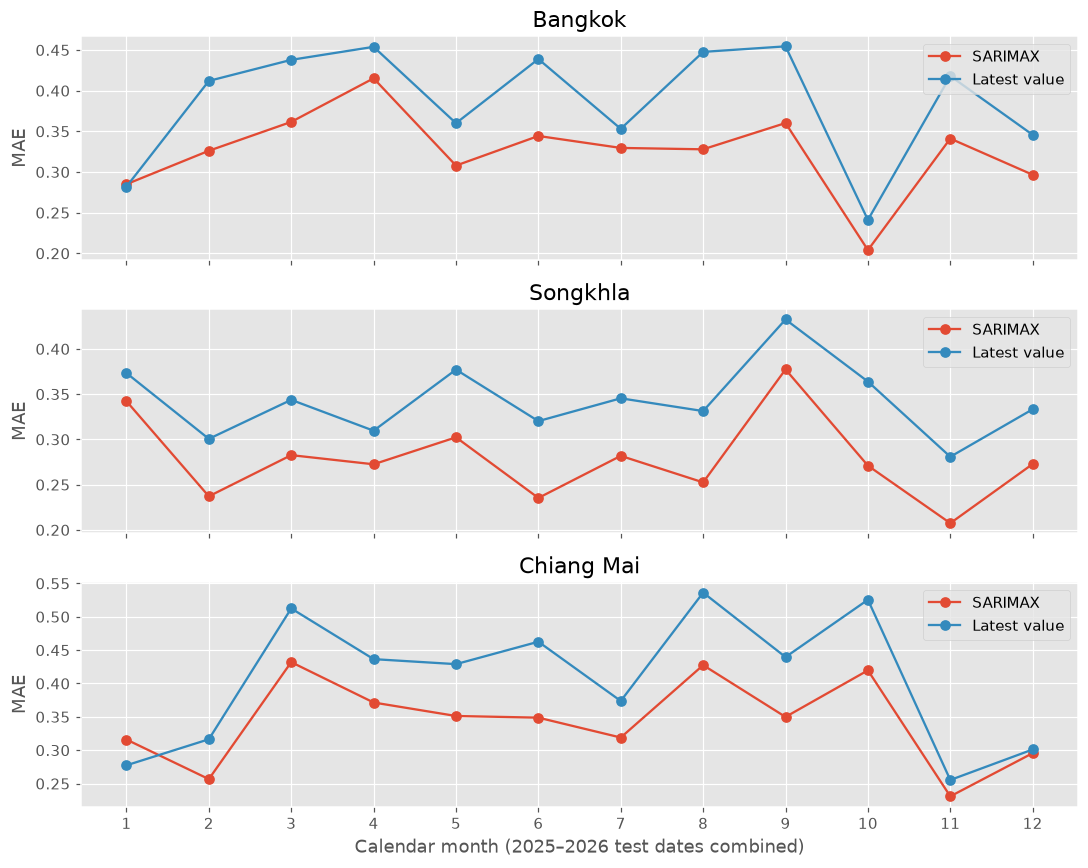

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, city in zip(axes, cities):
    monthly = audit["cities"][city]["by_month"]
    months = np.arange(1, 13)
    ax.plot(months, [monthly[str(month)]["model_mae"] for month in months], marker="o", label="SARIMAX")
    ax.plot(months, [monthly[str(month)]["persistence_mae"] for month in months],
            marker="o", label="Latest value")
    ax.set_title(CITY_LABELS[city])
    ax.set_ylabel("MAE")
    ax.legend(loc="upper right")
axes[-1].set_xticks(months)
axes[-1].set_xlabel("Calendar month (2025–2026 test dates combined)")
plt.tight_layout()
plt.show()

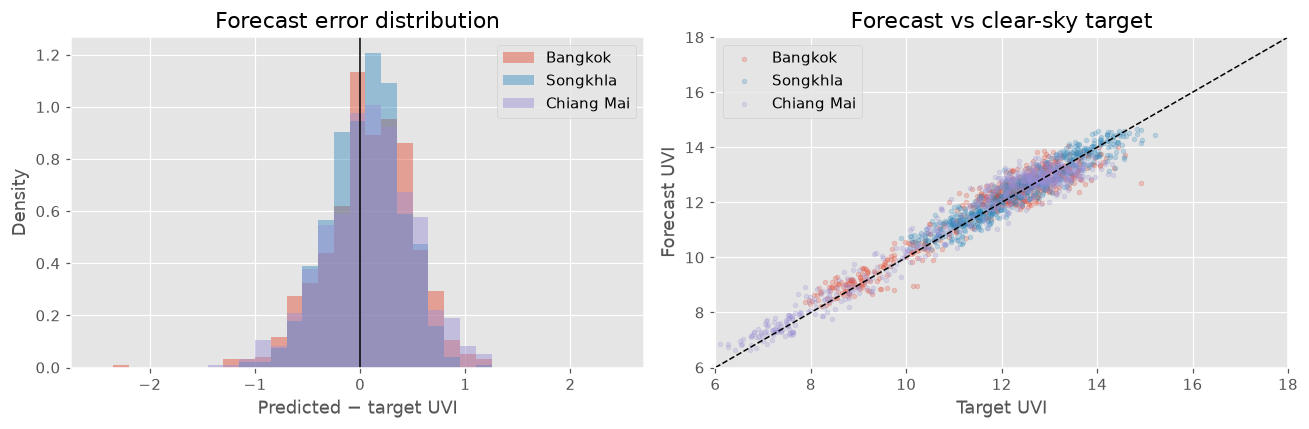

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for city, rows in rows_by_city.items():
    actual = np.array([float(row["actual"]) for row in rows])
    predicted = np.array([float(row["sarimax_h2"]) for row in rows])
    axes[0].hist(predicted - actual, bins=np.arange(-2.5, 2.6, 0.15), alpha=0.45,
                 density=True, label=CITY_LABELS[city])
    axes[1].scatter(actual, predicted, s=9, alpha=0.25, label=CITY_LABELS[city])
axes[0].axvline(0, color="black", lw=1)
axes[0].set(title="Forecast error distribution", xlabel="Predicted − target UVI", ylabel="Density")
axes[1].plot([6, 18], [6, 18], color="black", lw=1, ls="--")
axes[1].set(title="Forecast vs clear-sky target", xlabel="Target UVI", ylabel="Forecast UVI",
            xlim=(6, 18), ylim=(6, 18))
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

## 5. ความเสี่ยงใกล้จุดแบ่งระดับ UV

นับวันที่ค่าจริงหลังปัดเป็น UVI จำนวนเต็มถึงระดับ 8 หรือ 11 แต่ค่าทำนายยังต่ำกว่า ตารางและกราฟนี้ช่วยตรวจการพลาดคำเตือนระดับสูง ไม่ได้พิสูจน์ความแม่นยำของ UV ในวันที่มีเมฆ

In [12]:
lines = ["| City | UV ≥8 under-called / target days | UV ≥11 under-called / target days | "
         "Months beating latest-value baseline | 95% block-bootstrap MAE gain |",
         "|---|---:|---:|---:|---:|"]
for city in cities:
    result = audit["cities"][city]
    low8 = result["thresholds"]["8"]
    extreme = result["thresholds"]["11"]
    ci = result["mae_gain_95pct_block_bootstrap_ci"]
    lines.append(f"| {CITY_LABELS[city]} | {low8['undercalled']}/{low8['actual_at_or_above']} | "
                 f"{extreme['undercalled']}/{extreme['actual_at_or_above']} | "
                 f"{result['months_beating_persistence']}/12 | "
                 f"{result['mae_gain_over_persistence']:.4f} [{ci[0]:.4f}, {ci[1]:.4f}] |")
display(Markdown("\n".join(lines)))

| City | UV ≥8 under-called / target days | UV ≥11 under-called / target days | Months beating latest-value baseline | 95% block-bootstrap MAE gain |
|---|---:|---:|---:|---:|
| Bangkok | 0/635 | 3/492 | 11/12 | 0.0629 [0.0429, 0.0820] |
| Songkhla | 0/635 | 5/609 | 12/12 | 0.0633 [0.0492, 0.0776] |
| Chiang Mai | 9/578 | 2/447 | 11/12 | 0.0647 [0.0440, 0.0852] |

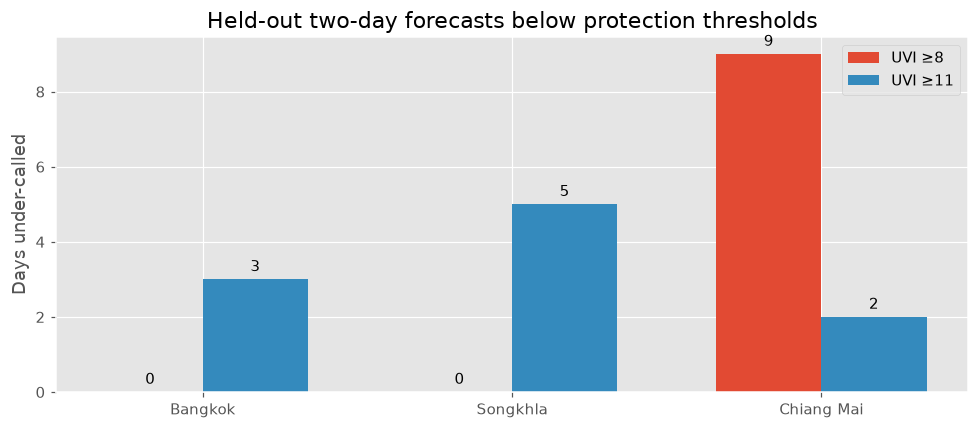

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cities))
width = 0.34
for offset, threshold in enumerate((8, 11)):
    undercalled = [audit["cities"][city]["thresholds"][str(threshold)]["undercalled"] for city in cities]
    bars = ax.bar(x + (offset - 0.5) * width, undercalled, width, label=f"UVI ≥{threshold}")
    ax.bar_label(bars, padding=3)
ax.set_xticks(x, [CITY_LABELS[city] for city in cities])
ax.set_ylabel("Days under-called")
ax.set_title("Held-out two-day forecasts below protection thresholds")
ax.legend()
plt.tight_layout()
plt.show()


## ข้อสรุปและขอบเขต

ผลประเมินนี้เป็นของ **clear-sky UV** ที่ TEMIS ประมาณ ณ เที่ยงสุริยะ ไม่ใช่การตรวจความถูกต้องของ UV จริงภายใต้เมฆหรือการสัมผัส UV ของผู้ใช้ Open-Meteo ใช้แสดงสภาพอากาศประกอบในแอป ไม่ใช่ feature ของ SARIMAX รายละเอียดเกณฑ์เผยแพร่และข้อจำกัดอยู่ใน `docs/uv-data-feasibility.md`